In [ ]:
import pandas as pd
import pandas as pd
import seaborn as sns

In [ ]:
dataset = pd.read_excel(r'Admission_St.xlsx')
dataset

,Admit,GRE,GPA,RANK
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4
...,...,...,...,...
395,0,620,4.00,2
396,0,560,3.04,3
397,0,460,2.63,2
398,0,700,3.65,2


In [ ]:
X = dataset.iloc[:,1:4]
Y = dataset.iloc[:,0:1]
Y.value_counts()

,count
Admit,
0,273
1,127


In [ ]:
dataset.describe()

,Admit,GRE,GPA,RANK
count,400.000000,400.000000,400.000000,400.00000
mean,0.317500,587.700000,3.389900,2.48500
std,0.466087,115.516536,0.380567,0.94446
min,0.000000,220.000000,2.260000,1.00000
25%,0.000000,520.000000,3.130000,2.00000
50%,0.000000,580.000000,3.395000,2.00000
75%,1.000000,660.000000,3.670000,3.00000
max,1.000000,800.000000,4.000000,4.00000


<Axes: xlabel='Admit', ylabel='count'>

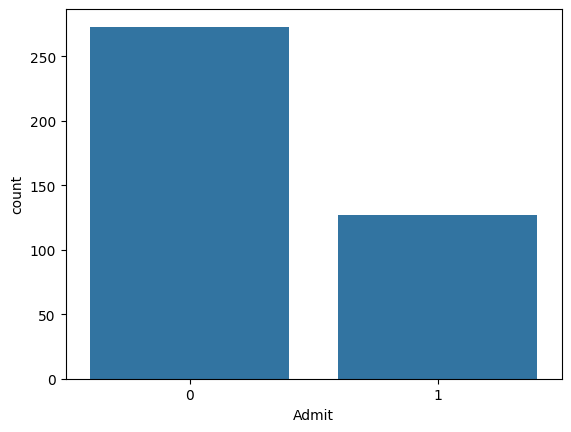

In [ ]:
sns.countplot(x="Admit", data=dataset)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.3, random_state=0)

In [ ]:
len(X_train)

280

In [ ]:
len(Y_train)

280

In [ ]:
len(X_test)

120

In [ ]:
len(Y_test)

120

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_score, recall_score, f1_score
model = LogisticRegression(max_iter=5000)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
acc1 = accuracy_score(Y_test, y_pred)
prec1 = precision_score(Y_test, y_pred)
rec1 = recall_score(Y_test, y_pred)
f11 = f1_score(Y_test, y_pred)

print("Before SMOTE")
print("Accuracy:", acc1)
print("Precision:", prec1)
print("Recall:", rec1)
print("F1 Score:", f11)
print("Classification report:\n", classification_report(Y_test, y_pred))

Before SMOTE
Accuracy: 0.7333333333333333
Precision: 0.7142857142857143
Recall: 0.2631578947368421
F1 Score: 0.38461538461538464
Classification report:
               precision    recall  f1-score   support

           0       0.74      0.95      0.83        82
           1       0.71      0.26      0.38        38

    accuracy                           0.73       120
   macro avg       0.73      0.61      0.61       120
weighted avg       0.73      0.73      0.69       120



In [ ]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=0)
X_ros, Y_ros = ros.fit_resample(X_train, Y_train)

In [ ]:
len(X_ros)

382

In [ ]:
Y_ros.value_counts()

,count
Admit,
0,191
1,191


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=0)
X_rus, Y_rus = rus.fit_resample(X_train, Y_train)

In [ ]:
Y_rus.value_counts()

,count
Admit,
0,89
1,89


In [ ]:
from imblearn.over_sampling import SMOTE
X_smote, Y_smote = SMOTE(k_neighbors=3).fit_resample(X_train, Y_train)

In [ ]:
Y_smote.value_counts()

,count
Admit,
0,191
1,191


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model_smote = LogisticRegression()
log_model_smote.fit(X_smote, Y_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
y_pred_smote = log_model_smote.predict(X_test)
y_prob_smote = log_model_smote.predict_proba(X_test)[:,1]

In [ ]:
acc2 = accuracy_score(Y_test, y_pred_smote)
prec2 = precision_score(Y_test, y_pred_smote)
rec2 = recall_score(Y_test, y_pred_smote)
f12 = f1_score(Y_test, y_pred_smote)

print("After SMOTE")
print("Accuracy:", acc2)
print("Precision:", prec2)
print("Recall:", rec2)
print("F1 Score:", f12)
print("Classification report:\n", classification_report(Y_test, y_pred_smote))

After SMOTE
Accuracy: 0.6666666666666666
Precision: 0.4791666666666667
Recall: 0.6052631578947368
F1 Score: 0.5348837209302325
Classification report:
               precision    recall  f1-score   support

           0       0.79      0.70      0.74        82
           1       0.48      0.61      0.53        38

    accuracy                           0.67       120
   macro avg       0.64      0.65      0.64       120
weighted avg       0.69      0.67      0.68       120



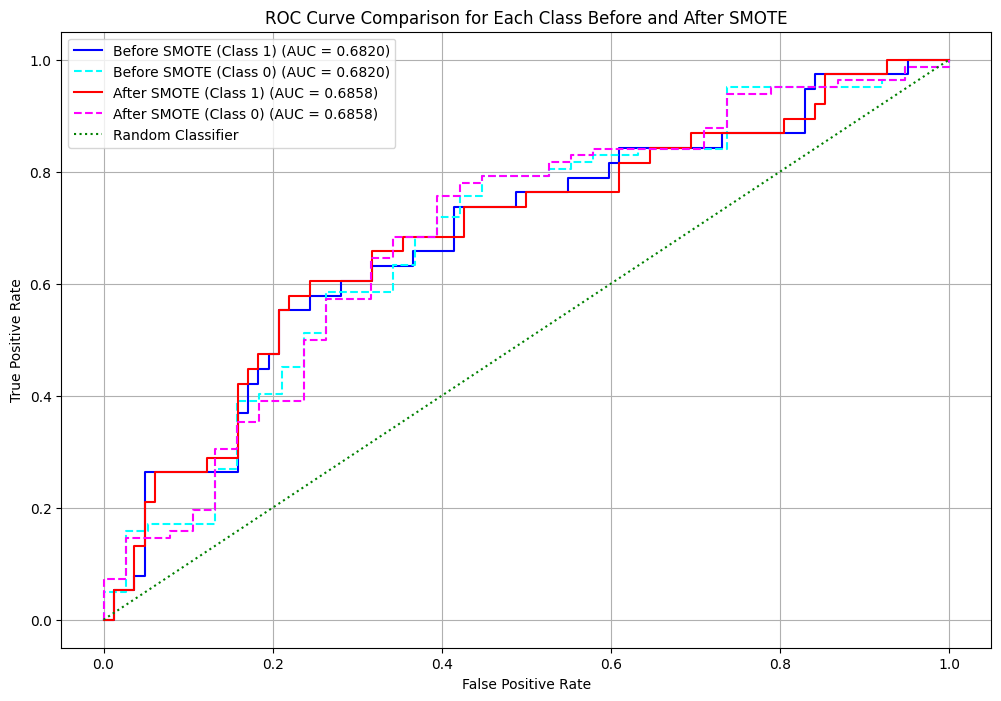


AUC Score Before SMOTE (Class 1): 0.6820
AUC Score Before SMOTE (Class 0): 0.6820
AUC Score After SMOTE (Class 1): 0.6858
AUC Score After SMOTE (Class 0): 0.6858


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Prepare true labels for class 0 (treating it as the positive class for its own ROC)
Y_test_class0_binary = (Y_test['Admit'] == 0).astype(int)
# For class 1, the original Y_test (which has 0s and 1s) is already suitable
Y_test_class1_binary = Y_test['Admit']

# --- Before SMOTE ---
# Probabilities for Class 0 before SMOTE
y_prob_before_class0 = model.predict_proba(X_test)[:,0]
# Probabilities for Class 1 before SMOTE (this is y_prob from previous steps)
y_prob_before_class1 = y_prob

# ROC for Class 1 (Admit=1) before SMOTE
fpr_before_class1, tpr_before_class1, _ = roc_curve(Y_test_class1_binary, y_prob_before_class1)
roc_auc_before_class1 = auc(fpr_before_class1, tpr_before_class1)

# ROC for Class 0 (Admit=0) before SMOTE
fpr_before_class0, tpr_before_class0, _ = roc_curve(Y_test_class0_binary, y_prob_before_class0)
roc_auc_before_class0 = auc(fpr_before_class0, tpr_before_class0)

# --- After SMOTE ---
# Probabilities for Class 0 after SMOTE
y_prob_after_class0 = log_model_smote.predict_proba(X_test)[:,0]
# Probabilities for Class 1 after SMOTE (this is y_prob_smote from previous steps)
y_prob_after_class1 = y_prob_smote

# ROC for Class 1 (Admit=1) after SMOTE
fpr_after_class1, tpr_after_class1, _ = roc_curve(Y_test_class1_binary, y_prob_after_class1)
roc_auc_after_class1 = auc(fpr_after_class1, tpr_after_class1)

# ROC for Class 0 (Admit=0) after SMOTE
fpr_after_class0, tpr_after_class0, _ = roc_curve(Y_test_class0_binary, y_prob_after_class0)
roc_auc_after_class0 = auc(fpr_after_class0, tpr_after_class0)

# --- Plotting all four ROC AUC curves ---
plt.figure(figsize=(12, 8))

plt.plot(fpr_before_class1, tpr_before_class1, color='blue', linestyle='-',
         label=f'Before SMOTE (Class 1) (AUC = {roc_auc_before_class1:.4f})')
plt.plot(fpr_before_class0, tpr_before_class0, color='cyan', linestyle='--',
         label=f'Before SMOTE (Class 0) (AUC = {roc_auc_before_class0:.4f})')

plt.plot(fpr_after_class1, tpr_after_class1, color='red', linestyle='-',
         label=f'After SMOTE (Class 1) (AUC = {roc_auc_after_class1:.4f})')
plt.plot(fpr_after_class0, tpr_after_class0, color='magenta', linestyle='--',
         label=f'After SMOTE (Class 0) (AUC = {roc_auc_after_class0:.4f})')

plt.plot([0, 1], [0, 1], color='green', linestyle=':', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison for Each Class Before and After SMOTE')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nAUC Score Before SMOTE (Class 1): {roc_auc_before_class1:.4f}")
print(f"AUC Score Before SMOTE (Class 0): {roc_auc_before_class0:.4f}")
print(f"AUC Score After SMOTE (Class 1): {roc_auc_after_class1:.4f}")
print(f"AUC Score After SMOTE (Class 0): {roc_auc_after_class0:.4f}")
